# Email Spam Detection
**Task 4 - OASIS INFOBYTE Data Science Internship**

Classify emails as spam or ham (non-spam) using Natural Language Processing and Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
%matplotlib inline

---
## 1. Load the Dataset

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

---
## 2. Exploratory Data Analysis

C:\Users\Admin\AppData\Local\Temp\ipykernel_18476\1988439009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


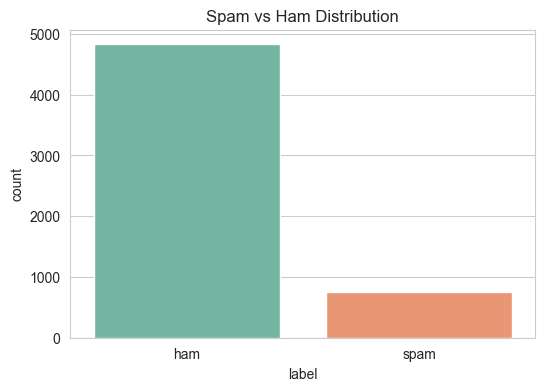

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Spam vs Ham Distribution')
plt.show()

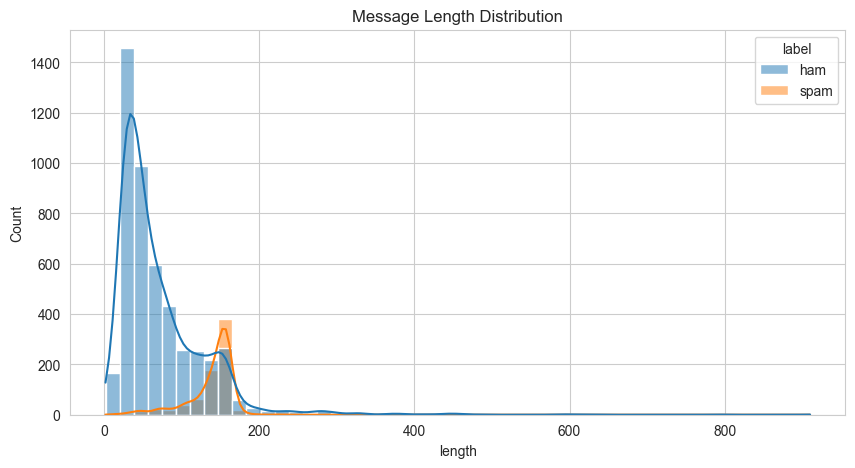

In [7]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution')
plt.show()

In [8]:
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


---
## 3. Data Preprocessing

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df['clean_message'] = df['message'].apply(clean_text)
df.head()

,label,message,length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah i dont think he goes to usf he lives aroun...


In [10]:
X = df['clean_message']
y = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 4457
Test samples: 1115


---
## 4. Model Training & Evaluation

In [11]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'SVM': SVC(kernel='linear')
}

results = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'\n{"="*40}')
    print(f'{name}')
    print(f'Accuracy: {acc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred))
    print(f'Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))


Naive Bayes
Accuracy: 0.9650

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115

Confusion Matrix:
[[965   1]
 [ 38 111]]

Logistic Regression
Accuracy: 0.9668

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115

Confusion Matrix:
[[965   1]
 [ 36 113]]

SVM
Accuracy: 0.9830

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    

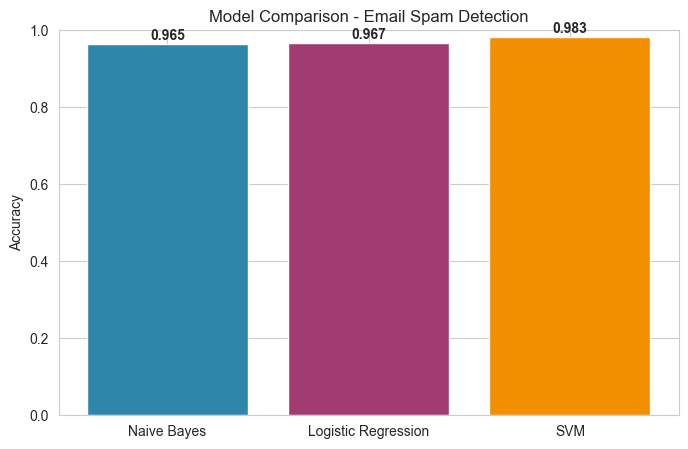

In [12]:
plt.figure(figsize=(8, 5))
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Model Comparison - Email Spam Detection')
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.show()

---
## 5. Test with Custom Messages

In [13]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f'Best model: {best_model_name} ({results[best_model_name]:.2%} accuracy)')

test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now.",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Update your password immediately."
]

for msg in test_messages:
    cleaned = clean_text(msg)
    vec = vectorizer.transform([cleaned])
    pred = best_model.predict(vec)[0]
    print(f"{'SPAM' if pred == 1 else 'HAM':>5} -> {msg}")

Best model: SVM (98.30% accuracy)
 SPAM -> Congratulations! You've won a free iPhone. Click here to claim now.
  HAM -> Hey, are we still meeting for lunch tomorrow?
 SPAM -> URGENT: Your account has been compromised. Update your password immediately.
